# DATA-445 In-Class Assignment 2

Consider the `Real_Estate.csv` data file posted on Blackboard (under the In-Class 2 assignment link). This file contains information related to 414 houses. The goal is to predict the house price of unit area.

## 1. (3 points) Using the pandas library, read the csv data file and create a data-frame called `house_price`.

In [1]:
import pandas as pd

house_price = pd.read_csv('Real_Estate.csv')
house_price.head()

,No,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 2. (3 points) Drop the `No` column.

In [2]:
# Dropping "no" column from the dataset
house_price = house_price.drop(columns=['No'], axis=1)
house_price.head()

,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 3. (4 points) Create a scatter plot of `house_age` and `house_price_of_unit_area`. Describe the plot.

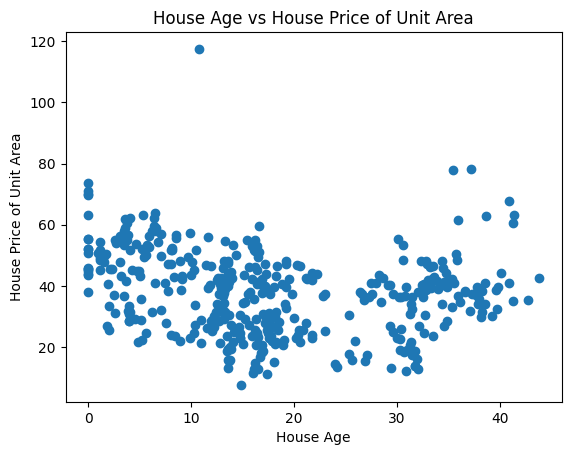

In [5]:
import matplotlib.pyplot as plt

plt.plot(house_price["house_age"], house_price["house_price_of_unit_area"], 'o')
plt.title("House Age vs House Price of Unit Area")
plt.xlabel("House Age")
plt.ylabel("House Price of Unit Area")
plt.show()

From the above scatter plot, we see that there are two groups of houses (newer (less than or equal to 25 years old) and older (greater than or equal to 25 years old)). the house price unit of unit area of each of these groups behave different (probably because of location and other features associated to the houses).

## 4. (4 points) Create a scatter plot of `distance_to_the_nearest_MRT_station` and `house_price_of_unit_area`. Describe the plot.

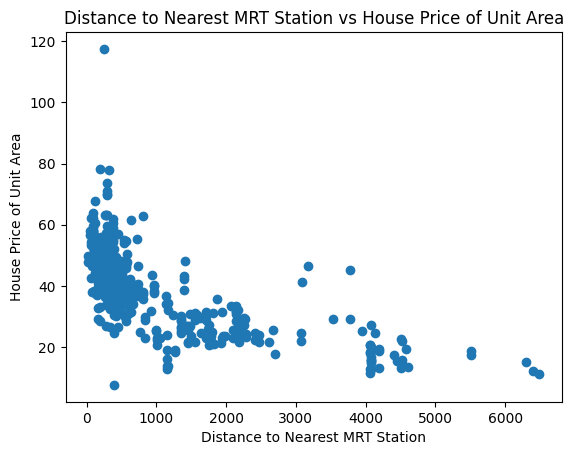

In [6]:
plt.plot(house_price["distance_to_the_nearest_MRT_station"], house_price["house_price_of_unit_area"], 'o')
plt.title("Distance to Nearest MRT Station vs House Price of Unit Area")
plt.xlabel("Distance to Nearest MRT Station")
plt.ylabel("House Price of Unit Area")
plt.show()

The closer the home is to the MRT station, on average, the higher house price unit area.

## 5. (5 points) Build a linear regression model

Input variables: `house_age`, `distance_to_the_nearest_MRT_station`, `number_of_convenience_stores`, `latitude`, and `longitude`.

Target variable: `house_price_of_unit_area`.

In [7]:
from sklearn.linear_model import LinearRegression

# Defining the input and target variables
X = house_price[["house_age", "distance_to_the_nearest_MRT_station", "number_of_convenience_stores",
                  "latitude", "longitude"]]
y = house_price["house_price_of_unit_area"]

# Creating a linear regression model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

## 6. (3 points) Using the model from part 5, predict the house price of unit area

For a house with: `house_age = 5`, `distance_to_the_nearest_MRT_station = 500`, `number_of_convenience_stores = 3`, `latitude = 24.98`, and `longitude = 121.49`.

In [9]:
# Defining the input variables for prediction
new_data = pd.DataFrame({
    "house_age": [5],
    "distance_to_the_nearest_MRT_station": [500],
    "number_of_convenience_stores": [3],
    "latitude": [24.98],
    "longitude": [121.49]
})

new_data.head()

,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude
0,5,500,3,24.98,121.49


In [10]:
#Predicting the house price of unit area for the new data
predicted_price = model.predict(new_data)
print(f"The predicted house price of unit area is: {predicted_price[0]:.2f}")

The predicted house price of unit area is: 45.56
